# Analyzing Car Prices Using Specifications and Features

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

Can we predict vehicle prices based on specifications, features, and market factors?

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

Which vehicle specifications and features have the greatest impact on car prices?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

Car prices will most likely increase as horsepower, engine size, vehicle weight, and  higher horsepower, larger engines, heavier vehicle weight, and the presence of premium or safety features. I expect horsepower and brand/trim level to have the strongest impact on price, while factors like fuel economy may have a smaller effect. The final answer would show measurable relationships and identify which variables most strongly predict price.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->


1. CSV: https://www.kaggle.com/datasets/metawave/vehicle-price-prediction
   Contains vehicle specs like engine size, horsepower, weight, and base price.

2. CSV: https://www.kaggle.com/datasets/makslypko/large-cars-dataset
    Includes additional features, trims, and other specifications.

3. API: Kelly Blue Book API
    Provides real-world market prices for each vehicle.

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

Step 1: Manipulation: Merge the two CSVs and API using make, model, year, and trim so each car has specs, features, and price on one table.

Step 2: Exploring: Check for missing data and find basic stats for variables like horsepower, weight, and price.

Step 3: Analyzing: See which features or specifications relate most to the price.

Step 4: Modeling: Build data visualations to show price predictions and dentify which features play the biggest roles.

Step 5: Summarize: Aggregate the findings into a report format to showcase the results.

## Data Imports, Quality Analysises, and Cleaning

In [1]:
# Start your code here
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
%matplotlib inline

c:\Users\BJaco\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#dataset 1
df = pd.read_csv("large cars dataset.csv")
df.head()

,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225,18,24,3880,115,197


In [3]:
#dataset 1 quality analysis
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         428 non-null    str    
 1   Model         428 non-null    str    
 2   VehicleClass  428 non-null    str    
 3   Region        428 non-null    str    
 4   DriveTrain    428 non-null    str    
 5   MSRP          428 non-null    str    
 6   DealerCost    428 non-null    str    
 7   EngineSize    428 non-null    float64
 8   Cylinders     426 non-null    float64
 9   HorsePower    428 non-null    int64  
 10  MPG_City      428 non-null    int64  
 11  MPG_Highway   428 non-null    int64  
 12  Weight        428 non-null    int64  
 13  Wheelbase     428 non-null    int64  
 14  Length        428 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 71.3 KB


np.int64(0)

In [4]:
#dataset 1 cleaning
df = df.drop_duplicates()
df = df.dropna()

In [5]:
#dataset 2
df = pd.read_csv("vehicle_price_prediction.csv")
df.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


In [6]:
#dataset 2 quality analysis
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   make              1000000 non-null  str    
 1   model             1000000 non-null  str    
 2   year              1000000 non-null  int64  
 3   mileage           1000000 non-null  int64  
 4   engine_hp         1000000 non-null  int64  
 5   transmission      1000000 non-null  str    
 6   fuel_type         1000000 non-null  str    
 7   drivetrain        1000000 non-null  str    
 8   body_type         1000000 non-null  str    
 9   exterior_color    1000000 non-null  str    
 10  interior_color    1000000 non-null  str    
 11  owner_count       1000000 non-null  int64  
 12  accident_history  249867 non-null   str    
 13  seller_type       1000000 non-null  str    
 14  condition         1000000 non-null  str    
 15  trim              1000000 non-null  str    
 16  vehicle_age 

np.int64(0)

In [7]:
#dataset 2 cleaning
df = df.drop_duplicates()
df = df.dropna()

## Visualizations

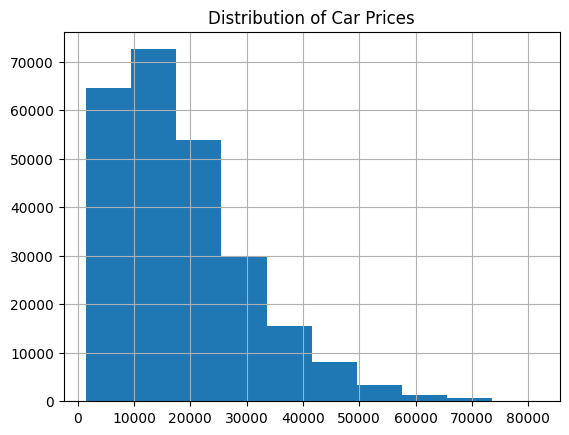

In [8]:
# Visualization 1: Distribution of Car Prices
df['price'].hist()
plt.title("Distribution of Car Prices")
plt.show()

This shows the distribution of car prices. Most cars are in the lower price range.

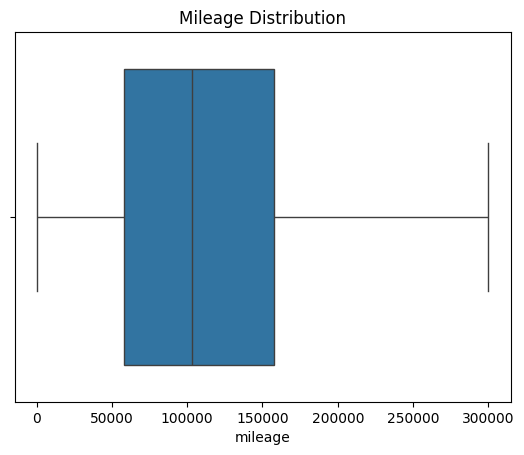

In [9]:
# Visualization 2: Relationship between Mileage and Price
sns.boxplot(x=df['mileage'])
plt.title("Mileage Distribution")
plt.show()

This shows mileage spread and highlights outliers with very high mileage.

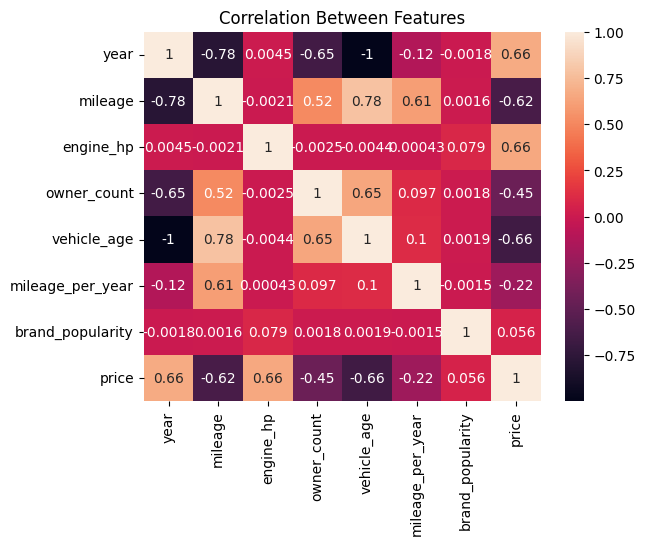

In [10]:
# Visualization 3: 
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Features")
plt.show()

This shows relationships between variables. Price is related to mileage, vehicle age, and horsepower.

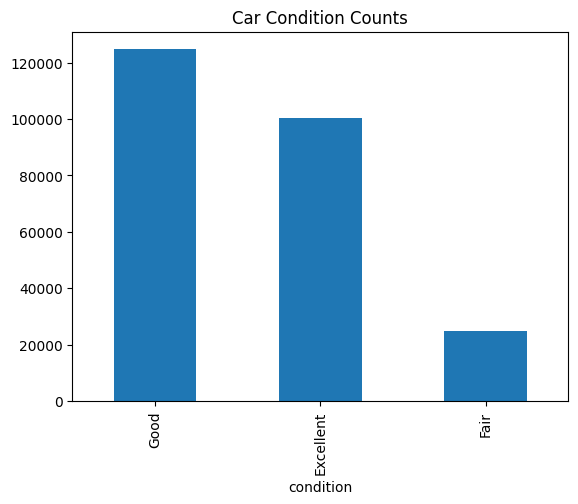

In [11]:
# Visualization 4: Car Condition Counts
df['condition'].value_counts().plot(kind='bar')
plt.title("Car Condition Counts")
plt.show()

Higher mileage generally leads to lower prices.

## Machine Learning

I plan to use regression to predict car prices based on features such as mileage, horsepower, and age. A challenge may be handling outliers and missing data.

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [12]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 1268 bytes to source.py
